📂 Cargando datos...
✓ 249 frames cargados

ALINEACIÓN SIM(3) — Umeyama (1991)

SIFT Classic:
  Escala (s)     : 0.6935
  Align RMSE     : 5.6258 m
  ATE RMSE       : 5.626 m
  RPE RMSE (Δ5)  : 1.117 m

SIFT Kornia:
  Escala (s)     : 0.6972
  Align RMSE     : 5.5862 m
  ATE RMSE       : 5.586 m
  RPE RMSE (Δ5)  : 1.081 m

Comparación:
  Mejor ATE      : Kornia  (1.01x más preciso)


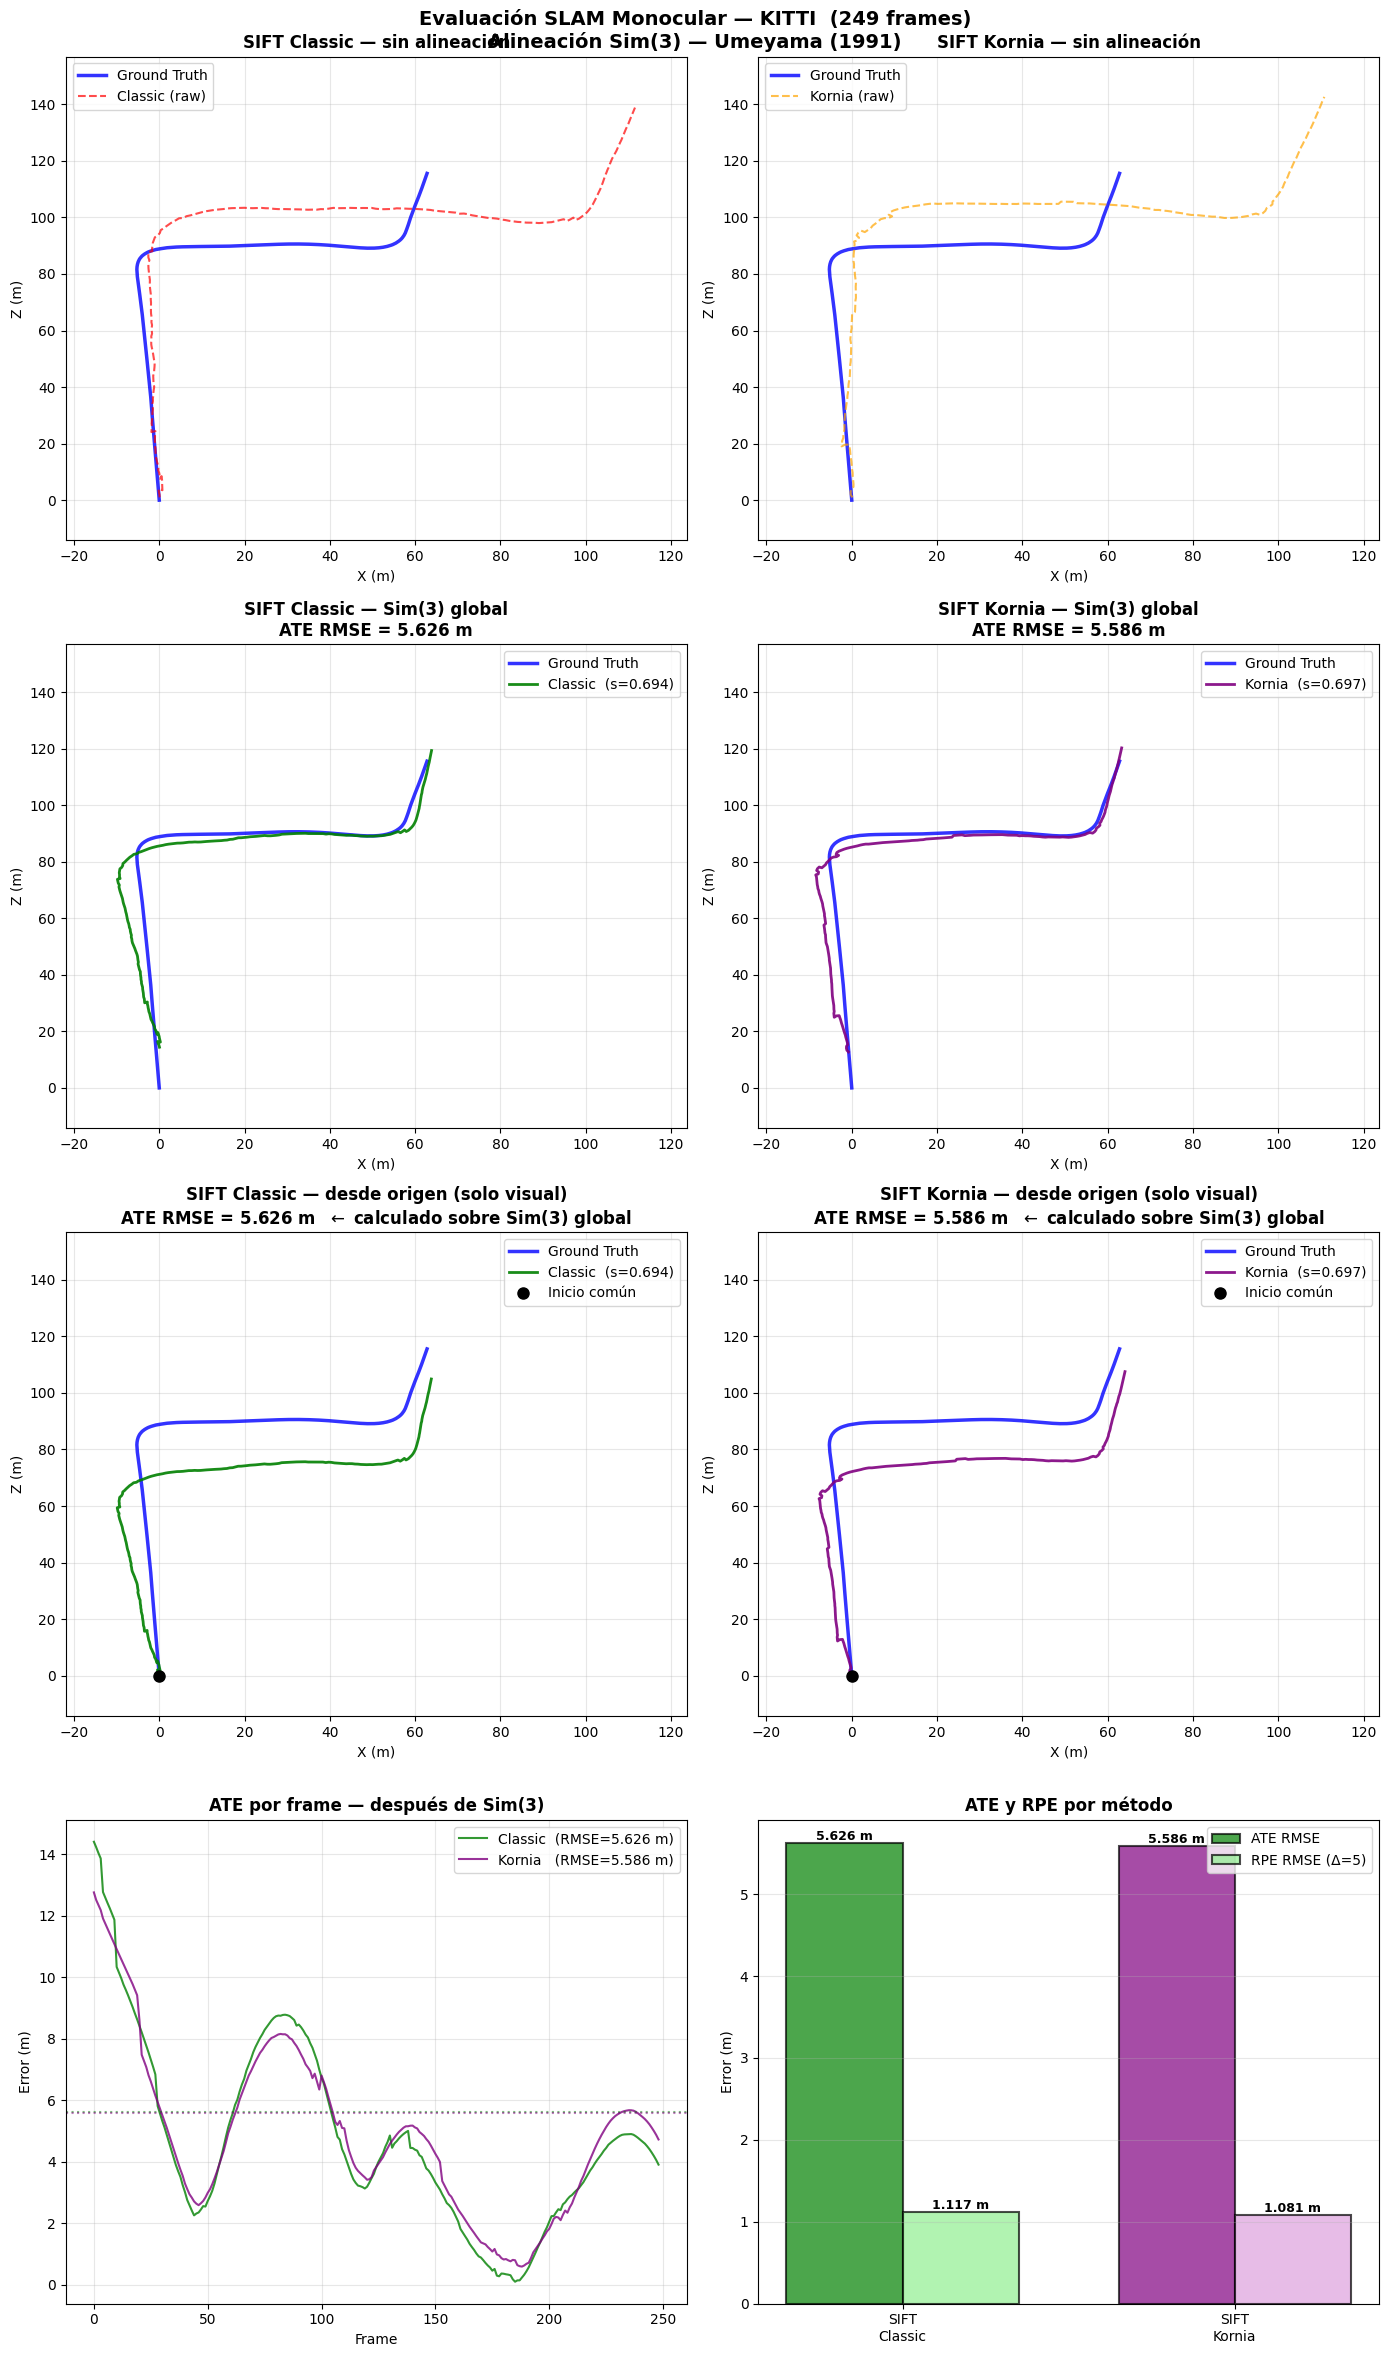

Guardado: outputs/benchmarks/slam_analysis_complete.png


In [5]:
# ============================================================================
# ANÁLISIS COMPLETO: Visual SLAM vs Ground Truth KITTI
# ============================================================================

import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================================
# SECCIÓN 1: IMPORTAR MÓDULOS DE ALINEACIÓN (fuente única de verdad)
# ============================================================================
import sys
sys.path.append('..')   # para que encuentre src/ desde notebooks/

from src.analysis.alignment import align_sim3_umeyama, apply_sim3_transform

def compute_ate(estimated_aligned: np.ndarray, ground_truth: np.ndarray) -> dict:
    errors = np.linalg.norm(estimated_aligned - ground_truth, axis=1)
    return {
        'rmse'  : float(np.sqrt(np.mean(errors ** 2))),
        'mean'  : float(np.mean(errors)),
        'std'   : float(np.std(errors)),
        'median': float(np.median(errors)),
        'min'   : float(np.min(errors)),
        'max'   : float(np.max(errors)),
    }

def compute_rpe(estimated_aligned: np.ndarray,
                ground_truth: np.ndarray, delta: int = 5) -> dict:
    est_delta = estimated_aligned[delta:] - estimated_aligned[:-delta]
    gt_delta  = ground_truth[delta:]      - ground_truth[:-delta]
    errors    = np.linalg.norm(est_delta - gt_delta, axis=1)
    return {
        'rmse'  : float(np.sqrt(np.mean(errors ** 2))),
        'mean'  : float(np.mean(errors)),
        'median': float(np.median(errors)),
        'delta' : delta,
    }


# ============================================================================
# SECCIÓN 2: CARGAR DATOS
# ============================================================================

def load_trajectory_json(filepath: str) -> np.ndarray:
    """Carga trayectoria desde JSON"""
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    traj = data['trajectory']
    
    # Manejar formato 2D (x, z) o 3D (x, y, z)
    if 'y' in traj:
        return np.array([[traj['x'][i], traj['y'][i], traj['z'][i]] 
                        for i in range(len(traj['x']))])
    else:
        return np.array([[traj['x'][i], 0.0, traj['z'][i]] 
                        for i in range(len(traj['x']))])


# Cargar datos
print("📂 Cargando datos...")

gt = load_trajectory_json('../outputs/benchmarks/ground_truth_trajectory.json')
classic = load_trajectory_json('../outputs/benchmarks/sift_classic_trajectory.json')
kornia = load_trajectory_json('../outputs/benchmarks/sift_kornia_trajectory.json')

# Ajustar longitud
min_len = min(len(gt), len(classic), len(kornia))
gt = gt[:min_len]
classic_raw = classic[:min_len]
kornia_raw = kornia[:min_len]

print(f"✓ {min_len} frames cargados\n")


# ============================================================================
# SECCIÓN 3: ALINEACIÓN SIM(3) Y MÉTRICAS
# ============================================================================

print("=" * 70)
print("ALINEACIÓN SIM(3) — Umeyama (1991)")
print("=" * 70)

# ── SIFT Classic ─────────────────────────────────────────────────────────────
R_c, t_c, s_c, err_c = align_sim3_umeyama(classic_raw, gt)
classic_aligned = apply_sim3_transform(classic_raw, R_c, t_c, s_c)

ate_c = compute_ate(classic_aligned, gt)
rpe_c = compute_rpe(classic_aligned, gt, delta=5)

print(f"\nSIFT Classic:")
print(f"  Escala (s)     : {s_c:.4f}")
print(f"  Align RMSE     : {err_c:.4f} m")
print(f"  ATE RMSE       : {ate_c['rmse']:.3f} m")
print(f"  RPE RMSE (Δ5)  : {rpe_c['rmse']:.3f} m")

# ── SIFT Kornia ──────────────────────────────────────────────────────────────
R_k, t_k, s_k, err_k = align_sim3_umeyama(kornia_raw, gt)
kornia_aligned = apply_sim3_transform(kornia_raw, R_k, t_k, s_k)

ate_k = compute_ate(kornia_aligned, gt)
rpe_k = compute_rpe(kornia_aligned, gt, delta=5)

print(f"\nSIFT Kornia:")
print(f"  Escala (s)     : {s_k:.4f}")
print(f"  Align RMSE     : {err_k:.4f} m")
print(f"  ATE RMSE       : {ate_k['rmse']:.3f} m")
print(f"  RPE RMSE (Δ5)  : {rpe_k['rmse']:.3f} m")

# ── Comparación ──────────────────────────────────────────────────────────────
print(f"\nComparación:")
mejor  = "Classic" if ate_c['rmse'] < ate_k['rmse'] else "Kornia"
ratio  = max(ate_c['rmse'], ate_k['rmse']) / min(ate_c['rmse'], ate_k['rmse'])
print(f"  Mejor ATE      : {mejor}  ({ratio:.2f}x más preciso)")
print("=" * 70)

# ============================================================================
# VISUALIZACIÓN: 8 GRÁFICAS (4 filas x 2 columnas)
# Classic (izquierda) vs Kornia (derecha), fila a fila
# ============================================================================

fig, axes = plt.subplots(4, 2, figsize=(14, 24))

# ── Límites globales: igual para todos los plots de trayectoria ───────────────
all_x = np.concatenate([
    gt[:, 0],
    classic_raw[:, 0],     kornia_raw[:, 0],
    classic_aligned[:, 0], kornia_aligned[:, 0],
])
all_z = np.concatenate([
    gt[:, 2],
    classic_raw[:, 2],     kornia_raw[:, 2],
    classic_aligned[:, 2], kornia_aligned[:, 2],
])
mx = (all_x.max() - all_x.min()) * 0.1
mz = (all_z.max() - all_z.min()) * 0.1
x_lim = [all_x.min() - mx, all_x.max() + mx]
z_lim = [all_z.min() - mz, all_z.max() + mz]

# Offset visual para fila 2: fuerza que frame 0 coincida con GT[0]
classic_origin = classic_aligned + (gt[0] - classic_aligned[0])
kornia_origin  = kornia_aligned  + (gt[0] - kornia_aligned[0])

# ── Fila 0: SIN alineación ───────────────────────────────────────────────────

ax = axes[0, 0]
ax.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax.plot(classic_raw[:, 0], classic_raw[:, 2], 'r--', linewidth=1.5,
        label='Classic (raw)', alpha=0.7)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title('SIFT Classic — sin alineación', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(x_lim)
ax.set_ylim(z_lim)

ax = axes[0, 1]
ax.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax.plot(kornia_raw[:, 0], kornia_raw[:, 2], color='orange', linestyle='--',
        linewidth=1.5, label='Kornia (raw)', alpha=0.7)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title('SIFT Kornia — sin alineación', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(x_lim)
ax.set_ylim(z_lim)

# ── Fila 1: Sim(3) global ────────────────────────────────────────────────────

ax = axes[1, 0]
ax.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax.plot(classic_aligned[:, 0], classic_aligned[:, 2], 'g-', linewidth=2,
        label=f'Classic  (s={s_c:.3f})', alpha=0.9)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title(f'SIFT Classic — Sim(3) global\nATE RMSE = {ate_c["rmse"]:.3f} m',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(x_lim)
ax.set_ylim(z_lim)

ax = axes[1, 1]
ax.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax.plot(kornia_aligned[:, 0], kornia_aligned[:, 2], 'purple', linewidth=2,
        label=f'Kornia  (s={s_k:.3f})', alpha=0.9)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title(f'SIFT Kornia — Sim(3) global\nATE RMSE = {ate_k["rmse"]:.3f} m',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(x_lim)
ax.set_ylim(z_lim)

# ── Fila 2: desde origen (solo visual) ───────────────────────────────────────

ax = axes[2, 0]
ax.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax.plot(classic_origin[:, 0], classic_origin[:, 2], 'g-', linewidth=2,
        label=f'Classic  (s={s_c:.3f})', alpha=0.9)
ax.plot(gt[0, 0], gt[0, 2], 'ko', markersize=8, label='Inicio común', zorder=5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title(f'SIFT Classic — desde origen (solo visual)\nATE RMSE = {ate_c["rmse"]:.3f} m  '
             r'$\leftarrow$ calculado sobre Sim(3) global',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(x_lim)
ax.set_ylim(z_lim)

ax = axes[2, 1]
ax.plot(gt[:, 0], gt[:, 2], 'b-', linewidth=2.5, label='Ground Truth', alpha=0.8)
ax.plot(kornia_origin[:, 0], kornia_origin[:, 2], 'purple', linewidth=2,
        label=f'Kornia  (s={s_k:.3f})', alpha=0.9)
ax.plot(gt[0, 0], gt[0, 2], 'ko', markersize=8, label='Inicio común', zorder=5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')
ax.set_title(f'SIFT Kornia — desde origen (solo visual)\nATE RMSE = {ate_k["rmse"]:.3f} m  '
             r'$\leftarrow$ calculado sobre Sim(3) global',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(x_lim)
ax.set_ylim(z_lim)

# ── Fila 3: métricas ─────────────────────────────────────────────────────────

# [3,0] ATE por frame
ax = axes[3, 0]
frames   = np.arange(min_len)
errors_c = np.linalg.norm(classic_aligned - gt, axis=1)
errors_k = np.linalg.norm(kornia_aligned  - gt, axis=1)

ax.plot(frames, errors_c, 'g-',           linewidth=1.5, alpha=0.8,
        label=f'Classic  (RMSE={ate_c["rmse"]:.3f} m)')
ax.plot(frames, errors_k, color='purple',  linewidth=1.5, alpha=0.8,
        label=f'Kornia   (RMSE={ate_k["rmse"]:.3f} m)')
ax.axhline(ate_c['rmse'], color='g',       linestyle=':', linewidth=1.5, alpha=0.5)
ax.axhline(ate_k['rmse'], color='purple',  linestyle=':', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Frame')
ax.set_ylabel('Error (m)')
ax.set_title('ATE por frame — después de Sim(3)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# [3,1] ATE + RPE barras
ax = axes[3, 1]
methods  = ['SIFT\nClassic', 'SIFT\nKornia']
ate_vals = [ate_c['rmse'], ate_k['rmse']]
rpe_vals = [rpe_c['rmse'], rpe_k['rmse']]
x        = np.arange(len(methods))
width    = 0.35

bars_ate = ax.bar(x - width / 2, ate_vals, width,
                  label='ATE RMSE',
                  color=['green', 'purple'], alpha=0.7,
                  edgecolor='black', linewidth=1.5)
bars_rpe = ax.bar(x + width / 2, rpe_vals, width,
                  label='RPE RMSE (Δ=5)',
                  color=['lightgreen', 'plum'], alpha=0.7,
                  edgecolor='black', linewidth=1.5)

for bar in list(bars_ate) + list(bars_rpe):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():.3f} m',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Error (m)')
ax.set_title('ATE y RPE por método', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# ── Título y guardado ─────────────────────────────────────────────────────────
plt.suptitle(
    f'Evaluación SLAM Monocular — KITTI  ({min_len} frames)\n'
    'Alineación Sim(3) — Umeyama (1991)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/benchmarks/slam_analysis_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: outputs/benchmarks/slam_analysis_complete.png")